In [1]:
import sys
from IPython.display import display, Javascript

def restart_kernel():
    """Restart the Jupyter Notebook kernel to reflect changes in modules and packages."""
    display(Javascript("Jupyter.notebook.kernel.restart()"))
    print("Kernel is restarting...")

restart_kernel()

import numpy as np
import torch
import tensorly as tl
from tensorly.decomposition import parafac
import sparse
import pickle
import os
import numpy.random as rn
import scipy.stats as st
from tensorly.cp_tensor import CPTensor
import matplotlib.pyplot as plt

from own_implementation import BPTF as BPTF
import bptf

# Please run everything up to the first bptf fit
# Thereafter, run each following cell on their own

<IPython.core.display.Javascript object>

Kernel is restarting...


# Helper functions

In [2]:
def generate(shp=(30, 30, 20, 10), K=5, alpha=0.1, beta=0.1):
    """Generate a count tensor from the BPTF model.

    PARAMS:
    shp -- (tuple) shape of the generated count tensor
    K -- (int) number of latent components
    alpha -- (float) shape parameter of gamma prior over factors
    beta -- (float) rate parameter of gamma prior over factors

    RETURNS:
    Mu -- (np.ndarray) true Poisson rates
    Y -- (np.ndarray) generated count tensor
    """
    Theta_DK_M = [rn.gamma(alpha, 1./beta, size=(D, K)) for D in shp]
    Theta_DK_M = [torch.tensor(factor) for factor in Theta_DK_M]
    Mu = tl.cp_to_tensor(CPTensor((None, Theta_DK_M)))
    assert Mu.shape == shp
    Y = rn.poisson(Mu)
    return Mu, Y

# Load data

In [3]:
use_existing_data = True

# for the first bptf.fit:
# using seed 100 causes the assert delta >= 0 to trip
# but using seed 0 doesn't
# please swap between the 2 seeds to get the 2 different types of assertion errors in the other cells
rn.seed(100)
device = 'cuda'

if use_existing_data:
    assert os.path.exists('sptensor.pkl'), 'No such file.'
    with open('sptensor.pkl', 'rb') as f:
        data = pickle.load(f)
    data = data[:, :, :, :24, :]
    data = torch.tensor(data.todense(), dtype=torch.float64, device=device)
else:
    data = generate(shp=(200, 200, 20, 24, 3), K=10)[1]
    data = torch.tensor(data, dtype=torch.float64, device=device)

# Building mask (base example)

In [4]:
mask = np.ones(data.shape)
# april of GDELT is set to missing
mask[:, :, :, 3, 1] = 0

# diagonals are set to missing
mask[np.eye(mask.shape[0]).astype(bool)] = 0
mask = torch.tensor(mask.astype(np.int64), dtype=torch.float64, device=device)

# Fit model

  0%|                                                                                                      | 0/500 [00:00<?, ?it/s]

ELBO = 12443079.191093665, change = 1.0021348916730144, time taken = 2.6222336292266846:   0%|             | 0/500 [00:02<?, ?it/s]

ELBO = 12443079.191093665, change = 1.0021348916730144, time taken = 2.6222336292266846:   0%|     | 1/500 [00:02<21:49,  2.62s/it]

ELBO = 12715163.867771298, change = 0.02186634614303364, time taken = 2.622670888900757:   0%|     | 1/500 [00:05<21:49,  2.62s/it]

ELBO = 12715163.867771298, change = 0.02186634614303364, time taken = 2.622670888900757:   0%|     | 2/500 [00:05<21:47,  2.62s/it]

...

ELBO = 26929796.56422149, change = 5.856084389761058e-07, time taken = 2.6371347904205322: 100%|▉| 499/500 [21:56<00:02,  2.64s/it]

ELBO = 26929812.469586052, change = 5.90623272028635e-07, time taken = 2.6400046348571777: 100%|▉| 499/500 [21:58<00:02,  2.64s/it]

ELBO = 26929812.469586052, change = 5.90623272028635e-07, time taken = 2.6400046348571777: 100%|█| 500/500 [21:58<00:00,  2.64s/it]

ELBO = 26929812.469586052, change = 5.90623272028635e-07, time taken = 2.6400046348571777: 100%|█| 500/500 [21:58<00:00,  2.64s/it]

Number of negative deltas: 0
When do they occur? []
what is their magnitude? []
List of elbos: [-5828435863.2233, 12443079.191093665, 12715163.867771298, 13574271.866243646, 15774521.717796106, 18344819.551837802, 20653946.604340885, 22353604.359968916, 23318864.186157152, 23919153.460353848, 24372661.742690686, 24729596.70235025, 25023892.406258818, 25271405.823021766, 25478470.41419763, 25649576.732129578, 25789728.998750936, 25904481.253042344, 26000028.472463567, 26080589.66196415, 26150550.088393625, 26213908.033798732, 26271662.22656206, 26322013.637307595, 26365766.2646354, 26405244.54988149, 26441359.78900801, 26473756.91051395, 26502530.03044877, 26528151.57776062, 26551085.29054927, 26571910.017634086, 26591101.480480045, 26608998.788344372, 26625876.678591672, 26641924.7812444, 26657207.24417052, 26671787.427826118, 26685560.99521115, 26698479.07303928, 26710554.856863406, 26721592.399662167, 26731757.571458463, 26741325.453131694, 26750085.808040734, 26758035.424377296, 267

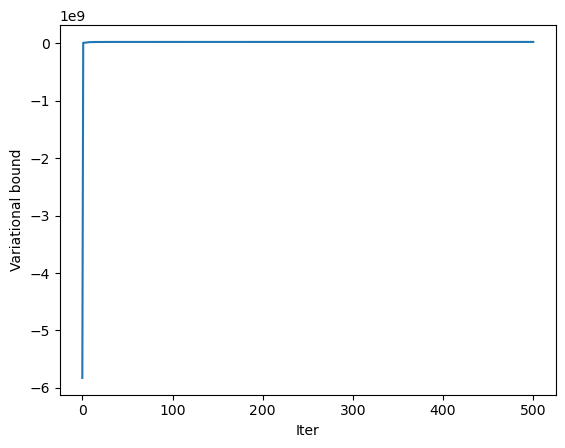

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([280, 280, 20, 24, 3]), device='cuda',
     n_components=50)

In [5]:
n_components = 50
max_iter = 500
tol = 1e-10

BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = mask, max_iter = max_iter, verbose=True, tol=tol)

# Mask with last mode completely masked

  0%|                                                                                                      | 0/500 [00:00<?, ?it/s]

ELBO = 12565886.740758585, change = 1.0022711895342442, time taken = 2.6364221572875977:   0%|             | 0/500 [00:02<?, ?it/s]

ELBO = 12565886.740758585, change = 1.0022711895342442, time taken = 2.6364221572875977:   0%|     | 1/500 [00:02<21:56,  2.64s/it]

ELBO = 12807090.504040288, change = 0.019195124726004164, time taken = 2.6374385356903076:   0%|   | 1/500 [00:05<21:56,  2.64s/it]

ELBO = 12807090.504040288, change = 0.019195124726004164, time taken = 2.6374385356903076:   0%|   | 2/500 [00:05<21:54,  2.64s/it]

...

ELBO = 27060855.666407507, change = 1.3963012945071925e-08, time taken = 2.6374106407165527: 100%|▉| 499/500 [21:56<00:02,  2.64s/i

ELBO = 27060856.042208564, change = 1.3887256975763942e-08, time taken = 2.636408567428589: 100%|▉| 499/500 [21:59<00:02,  2.64s/it

ELBO = 27060856.042208564, change = 1.3887256975763942e-08, time taken = 2.636408567428589: 100%|█| 500/500 [21:59<00:00,  2.64s/it

ELBO = 27060856.042208564, change = 1.3887256975763942e-08, time taken = 2.636408567428589: 100%|█| 500/500 [21:59<00:00,  2.64s/it

Number of negative deltas: 0
When do they occur? []
what is their magnitude? []
List of elbos: [-5532733640.805635, 12565886.740758585, 12807090.504040288, 13613737.52017526, 15497123.285967607, 17895146.155627202, 20127733.653914392, 22026356.44909553, 23359084.210474018, 24223632.320480097, 24792062.537389178, 25180505.92945676, 25465929.624996122, 25683838.27174707, 25857971.191558655, 26009847.86633852, 26137170.696097314, 26233758.657271195, 26312030.049051344, 26379164.407670543, 26437961.198111206, 26489520.3179648, 26534398.586654726, 26573475.150622874, 26608093.560020953, 26640328.009570476, 26672044.821913876, 26700174.229207203, 26722483.681948315, 26740869.326425694, 26756761.55666563, 26770838.07416563, 26783567.36326936, 26795249.394071113, 26806097.05585156, 26816232.17368057, 26825734.314839363, 26834668.726772536, 26843081.00888791, 26851041.832084514, 26858642.480657853, 26866011.936288282, 26873308.257459637, 26880595.436739873, 26887653.583243374, 26894173.55431318

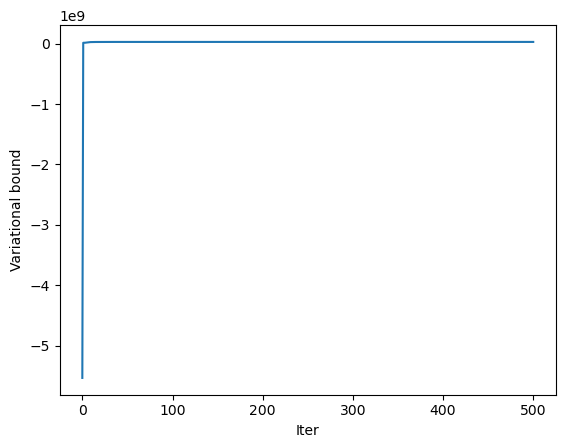

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([280, 280, 20, 24, 3]), device='cuda',
     n_components=50)

In [6]:
mask = np.ones(data.shape)
# april of GDELT is set to missing
mask[:, :, :, 3, :] = 0

# diagonals are set to missing
mask[np.eye(mask.shape[0]).astype(bool)] = 0
mask = torch.tensor(mask.astype(np.int64), dtype=torch.float64, device=device)

BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = mask, max_iter = max_iter, verbose=True, tol=tol)

# Mask with the 1st and 3rd indices masked

  0%|                                                                                                      | 0/500 [00:00<?, ?it/s]

ELBO = 12956991.17225458, change = 1.0023229845121866, time taken = 2.6393556594848633:   0%|              | 0/500 [00:02<?, ?it/s]

ELBO = 12956991.17225458, change = 1.0023229845121866, time taken = 2.6393556594848633:   0%|      | 1/500 [00:02<21:57,  2.64s/it]

ELBO = 13505039.05551158, change = 0.04229746520400219, time taken = 2.637934684753418:   0%|      | 1/500 [00:05<21:57,  2.64s/it]

ELBO = 13505039.05551158, change = 0.04229746520400219, time taken = 2.637934684753418:   0%|      | 2/500 [00:05<21:54,  2.64s/it]

...

ELBO = 28114475.280320063, change = 7.167774417776399e-09, time taken = 2.639669418334961: 100%|▉| 499/500 [21:56<00:02,  2.64s/it]

ELBO = 28114475.490818243, change = 7.487181536969318e-09, time taken = 2.6373846530914307: 100%|▉| 499/500 [21:59<00:02,  2.64s/it

ELBO = 28114475.490818243, change = 7.487181536969318e-09, time taken = 2.6373846530914307: 100%|█| 500/500 [21:59<00:00,  2.64s/it

ELBO = 28114475.490818243, change = 7.487181536969318e-09, time taken = 2.6373846530914307: 100%|█| 500/500 [21:59<00:00,  2.64s/it

Number of negative deltas: 0
When do they occur? []
what is their magnitude? []
List of elbos: [-5577734635.888243, 12956991.17225458, 13505039.05551158, 14314924.972747771, 16442569.946215076, 19213158.63982265, 21571944.65934875, 23243819.80272999, 24379504.267505568, 25116818.614574715, 25635075.71427928, 26043264.956633136, 26355497.245528195, 26588983.043376338, 26767918.332979444, 26914962.274631515, 27046483.887512233, 27163288.556418832, 27262106.836043637, 27343828.821679365, 27411343.168413807, 27470147.71316299, 27523168.762191325, 27570352.829097018, 27610598.812926676, 27644388.978368692, 27673178.730085306, 27698075.312002994, 27719897.54587636, 27739337.679007392, 27757017.2795091, 27773430.28240719, 27789108.98945922, 27804332.98603619, 27818904.909724314, 27832307.370161097, 27844230.958932985, 27854744.49690927, 27864059.94302121, 27872408.36996134, 27879958.740865145, 27886832.548942406, 27893125.16887142, 27898922.590846207, 27904292.84852606, 27909320.573472884, 27

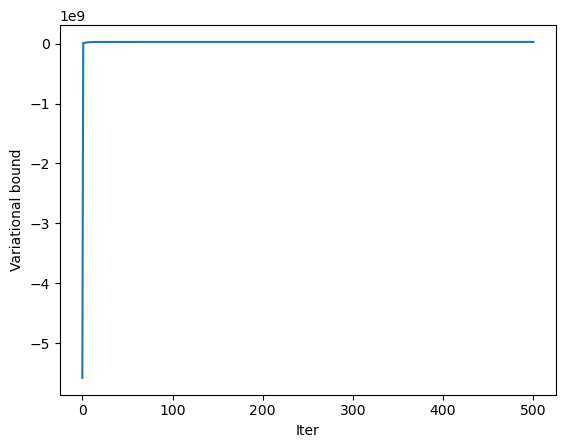

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([280, 280, 20, 24, 3]), device='cuda',
     n_components=50)

In [7]:
mask = np.ones(data.shape)
# april is set to missing
mask[:, :, :, 3, [0, 2]] = 0

# diagonals are set to missing
mask[np.eye(mask.shape[0]).astype(bool)] = 0
mask = torch.tensor(mask.astype(np.int64), dtype=torch.float64, device=device)

BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = mask, max_iter = max_iter, verbose=True, tol=tol)

# Mask with only diagonals masked

In [8]:
mask = np.ones(data.shape)

# diagonals are set to missing
mask[np.eye(mask.shape[0]).astype(bool)] = 0
mask = torch.tensor(mask.astype(np.int64), dtype=torch.float64, device=device)

BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = mask, max_iter = max_iter, verbose=True, tol=tol)

  0%|                                                                                                      | 0/500 [00:00<?, ?it/s]

ELBO = 13190501.397890123, change = 1.0022355803715746, time taken = 2.6364893913269043:   0%|             | 0/500 [00:02<?, ?it/s]

ELBO = 13190501.397890123, change = 1.0022355803715746, time taken = 2.6364893913269043:   0%|     | 1/500 [00:02<21:56,  2.64s/it]

ELBO = 13502778.566831052, change = 0.023674397168168285, time taken = 2.6349878311157227:   0%|   | 1/500 [00:05<21:56,  2.64s/it]

ELBO = 13502778.566831052, change = 0.023674397168168285, time taken = 2.6349878311157227:   0%|   | 2/500 [00:05<21:53,  2.64s/it]

...

ELBO = 28215741.82576473, change = 6.993963107777146e-08, time taken = 2.640300750732422:  75%|█▌| 376/500 [16:32<05:27,  2.64s/it]

ELBO = 28215743.487887166, change = 5.890762844838788e-08, time taken = 2.6403026580810547:  75%|▊| 376/500 [16:35<05:27,  2.64s/it

ELBO = 28215743.487887166, change = 5.890762844838788e-08, time taken = 2.6403026580810547:  75%|▊| 377/500 [16:35<05:24,  2.64s/it

ELBO = 28215743.487887166, change = 5.890762844838788e-08, time taken = 2.6403026580810547:  75%|▊| 377/500 [16:36<05:25,  2.64s/it

KeyboardInterrupt: 

# No mask

In [ ]:
BPTF_model = BPTF(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model.fit(data, mask = None, max_iter = max_iter, verbose=True, tol=tol)